## **Task 1: Data Loading & Exploratory Data Analysis (EDA)**

#### Load the dataset 

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('dataset/Mall_Customers.csv')

#### Rename and drop columns 

In [3]:
df.head(10)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
5,6,Female,22,17,76
6,7,Female,35,18,6
7,8,Female,23,18,94
8,9,Male,64,19,3
9,10,Female,30,19,72


In [4]:
df.drop(columns=['CustomerID'],inplace=True)

In [5]:
df.rename(columns={'Annual Income (k$)':'AnnualIncome','Spending Score (1-100)':'SpendingScore'},inplace=True)

In [6]:
df.describe()

,Age,AnnualIncome,SpendingScore
count,200.000000,200.000000,200.000000
mean,38.850000,60.560000,50.200000
std,13.969007,26.264721,25.823522
min,18.000000,15.000000,1.000000
25%,28.750000,41.500000,34.750000
50%,36.000000,61.500000,50.000000
75%,49.000000,78.000000,73.000000
max,70.000000,137.000000,99.000000


---

Numerical Data doesn't Contain Outliers by looking at Statstic of Data. 

---

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Gender         200 non-null    object
 1   Age            200 non-null    int64 
 2   AnnualIncome   200 non-null    int64 
 3   SpendingScore  200 non-null    int64 
dtypes: int64(3), object(1)
memory usage: 6.4+ KB


---

DataSet Contains **3** Numerical columns and **1** Categorical Column so We will Apply Label Encoding in Categorical Column and Feature Scaling in Numerical Columns.

---

In [8]:
df['Gender'].value_counts()

Gender
Female    112
Male       88
Name: count, dtype: int64

---

We Nearly have 60-40 split in Customer Based on Gender

---

#### Univariate distributions 

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
sns.set_style('whitegrid')

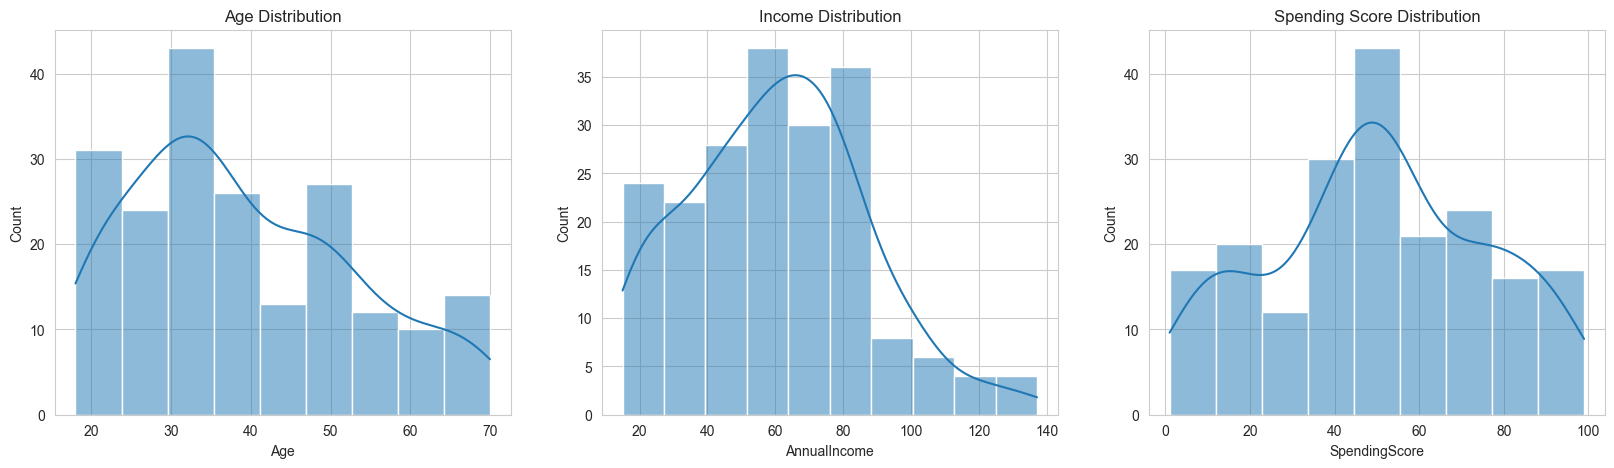

In [11]:
_,ax = plt.subplots(1,3,figsize=(20,5))

sns.histplot(data=df,x='Age',ax=ax[0],kde=True)
ax[0].set_title('Age Distribution')

sns.histplot(data=df,x='AnnualIncome',ax=ax[1],kde=True)
ax[1].set_title('Income Distribution')

sns.histplot(data=df,x='SpendingScore',ax=ax[2],kde=True)
ax[2].set_title('Spending Score Distribution')

plt.show()

---

**Key Takeaways from the Plots:**

* **Age**: The customer base peaks around the 30–35 age range. It's a bit right-skewed, trailing off as age increases up to 70, with a decent spike in younger customers (around 18–20).

* **Annual Income**: This follows a fairly normal distribution but is slightly right-skewed. The bulk of your customers earn between 40k and 80k, with a few high earners stretching out past 100k up to nearly 140k.

* **Spending Score**: This shows a clear, massive peak right in the middle around 40–50. The rest of the distribution is relatively uniform across the lower and higher scores.

---

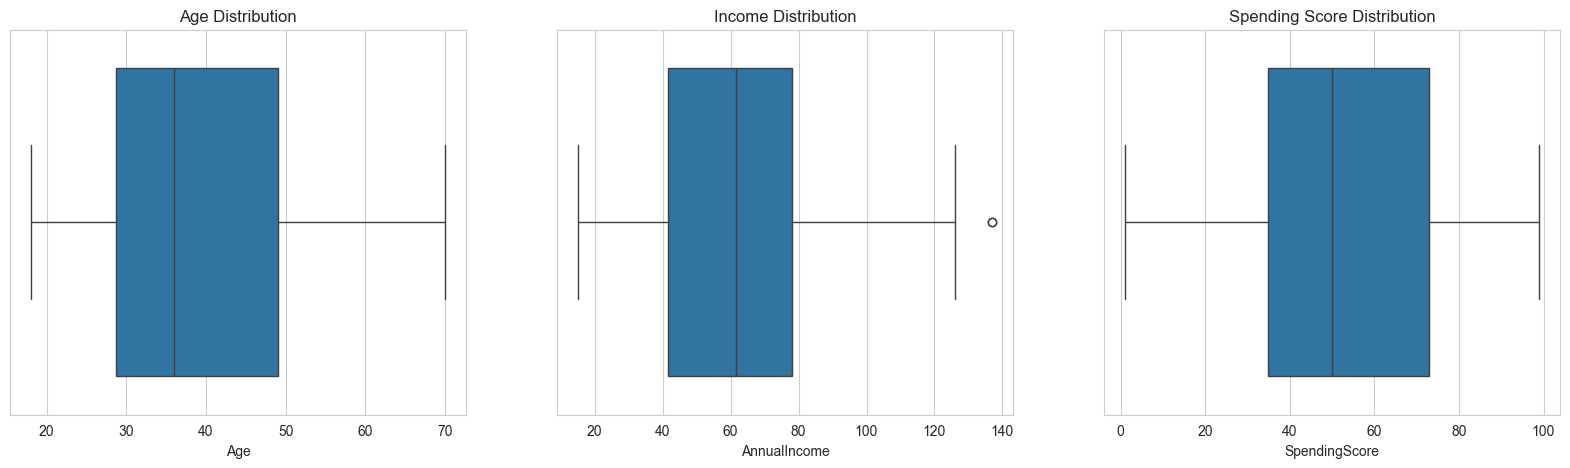

In [12]:
_,ax = plt.subplots(1,3,figsize=(20,5))

sns.boxplot(data=df,x='Age',ax=ax[0])
ax[0].set_title('Age Distribution')

sns.boxplot(data=df,x='AnnualIncome',ax=ax[1])
ax[1].set_title('Income Distribution')

sns.boxplot(data=df,x='SpendingScore',ax=ax[2])
ax[2].set_title('Spending Score Distribution')

plt.show()

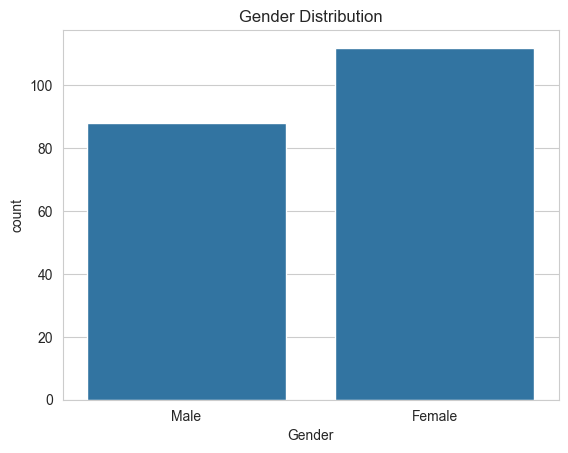

In [13]:
sns.countplot(data=df,x='Gender')
plt.title('Gender Distribution')

plt.show()

#### Bivariate Analysis 

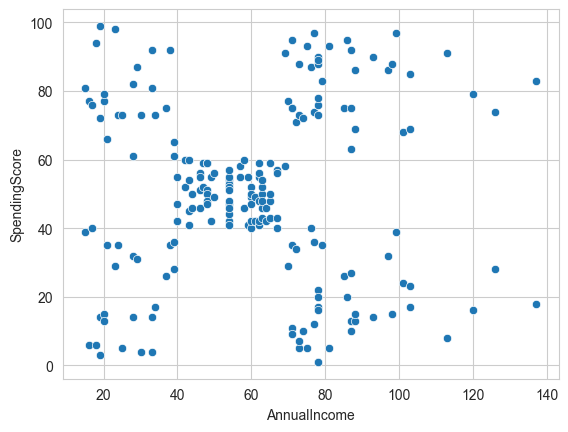

In [14]:
sns.scatterplot(data=df,x='AnnualIncome',y='SpendingScore')
plt.title('')

plt.show()

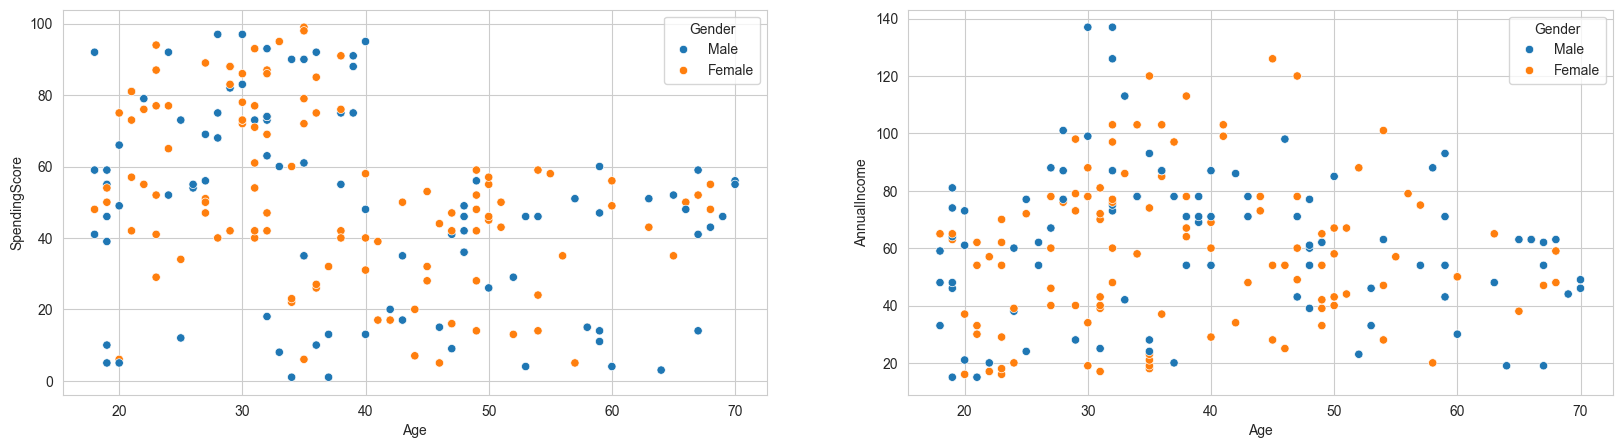

In [15]:
_,ax = plt.subplots(1,2,figsize=(20,5))

sns.scatterplot(data=df,x='Age',y='SpendingScore',hue='Gender',ax=ax[0])
ax[0].set_title('')

sns.scatterplot(data=df,x='Age',y='AnnualIncome',hue='Gender',ax=ax[1])
ax[1].set_title('')

plt.show()

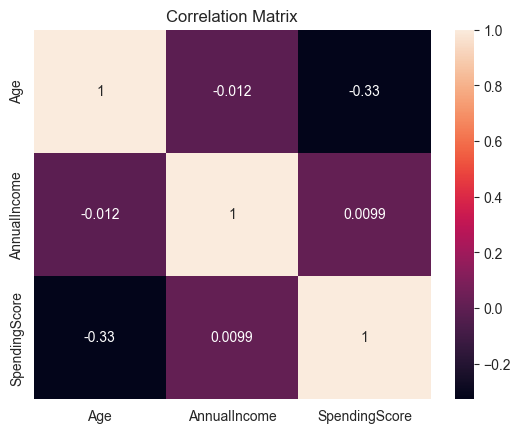

In [16]:
sns.heatmap(df.corr(numeric_only=True),annot=True)
plt.title('Correlation Matrix')

plt.show()

#### 1.4  Gender-Wise Summary 

In [17]:
grouped_data = df.groupby('Gender')[['Age','AnnualIncome','SpendingScore']].mean()
grouped_data

,Age,AnnualIncome,SpendingScore
Gender,,,
Female,38.098214,59.250000,51.526786
Male,39.806818,62.227273,48.511364


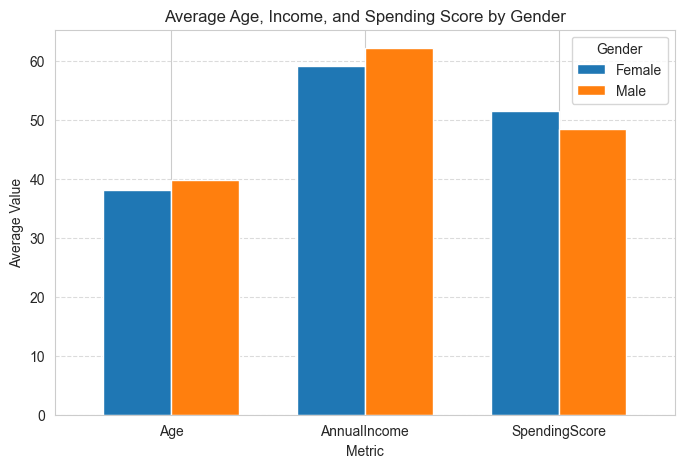

In [18]:
ax = grouped_data.T.plot(kind="bar", figsize=(8, 5), width=0.7)

plt.title("Average Age, Income, and Spending Score by Gender")
plt.xlabel("Metric")
plt.ylabel("Average Value")
plt.xticks(rotation=0)  
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.show()

## **Task 2: Feature Scaling & Feature Selection**

#### Encode Gender 

In [19]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Gender_enc'] = le.fit_transform(df['Gender'])

---

By Default 0 was Assigned to Female and 1 was Assigned to Male because of Alphabetical Order.

---

####  Engineer New Features 

In [59]:
income_group_names = ["Low", "Medium", "High"]

In [60]:
df['IncomeGroup'] = pd.qcut(df['AnnualIncome'],q=3,labels=income_group_names)

df['IncomeGroup'].value_counts()

IncomeGroup
Low       70
High      66
Medium    64
Name: count, dtype: int64

In [48]:
age_custom_bins = [18, 25, 40, 55, 70]
age_custom_labels = ["Young", "Adult", "Middle Aged", "Senior"]

In [57]:
df['AgeGroup'] = pd.cut(
    df["Age"], 
    bins=age_custom_bins, 
    labels=age_custom_labels
)

df['AgeGroup'].value_counts()

AgeGroup
Adult          84
Middle Aged    49
Young          34
Senior         29
Name: count, dtype: int64

In [50]:
score_custom_bins = [0,33,66,100]
score_custom_labels = ["Low", "Medium", "High"]

In [56]:
df['SpendingCategory'] = pd.cut(
    df["SpendingScore"], 
    bins=score_custom_bins, 
    labels=score_custom_labels
)

df['SpendingCategory'].value_counts()

SpendingCategory
Medium    94
High      57
Low       49
Name: count, dtype: int64

In [67]:
# Income and Score Columns only
X_2d = df[['AnnualIncome','SpendingScore']]

In [68]:
X_5d =  df[['Age', 'AnnualIncome', 'SpendingScore', 'Gender_enc']] 

#### Scale features 

In [20]:
from sklearn.preprocessing import StandardScaler

In [69]:
scaler_2d = StandardScaler()
scaler_5d = StandardScaler()

In [70]:
# Scaling values into new df 

X_2d_scaled = pd.DataFrame(scaler_2d.fit_transform(X_2d),columns=X_2d.columns)
X_5d_scaled = pd.DataFrame(scaler_5d.fit_transform(X_5d),columns=X_5d.columns)

In [86]:
print(f'Mean: \n{X_2d_scaled.mean().round(2)}')
print()
print(f'Std: \n{X_2d_scaled.std().round(2)}')

Mean: 
AnnualIncome    -0.0
SpendingScore   -0.0
dtype: float64

Std: 
AnnualIncome     1.0
SpendingScore    1.0
dtype: float64


In [87]:
print(f'Mean: \n{X_5d_scaled.mean().round(2)}')
print()
print(f'Std: \n{X_5d_scaled.std().round(2)}')

Mean: 
Age             -0.0
AnnualIncome    -0.0
SpendingScore   -0.0
Gender_enc       0.0
dtype: float64

Std: 
Age              1.0
AnnualIncome     1.0
SpendingScore    1.0
Gender_enc       1.0
dtype: float64


## **Task 3: K-Means Clustering**

#### Elbow Method 

In [25]:
from sklearn.cluster import KMeans

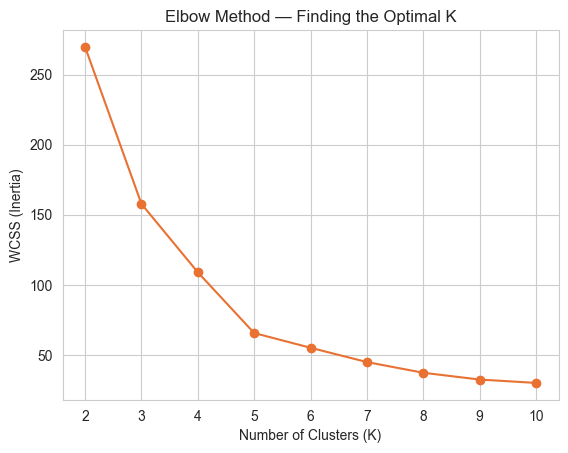

K = 2  ->  WCSS = 269.7
K = 3  ->  WCSS = 157.7
K = 4  ->  WCSS = 108.9
K = 5  ->  WCSS = 65.6
K = 6  ->  WCSS = 55.1
K = 7  ->  WCSS = 44.9
K = 8  ->  WCSS = 37.2
K = 9  ->  WCSS = 32.4
K = 10  ->  WCSS = 30.0


In [89]:
wcss = []
k_ranges = range(2, 11)

for k in k_ranges:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    km.fit(X_2d_scaled)
    wcss.append(km.inertia_)

plt.plot(list(k_ranges), wcss, marker="o", color="#E97132")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS (Inertia)")
plt.title("Elbow Method \u2014 Finding the Optimal K")
plt.xticks(list(k_ranges))
plt.show()

for k, w in zip(k_ranges, wcss):
    print(f"K = {k}  ->  WCSS = {w:,.1f}")

#### Silhouette Score

In [27]:
from sklearn.metrics import silhouette_score

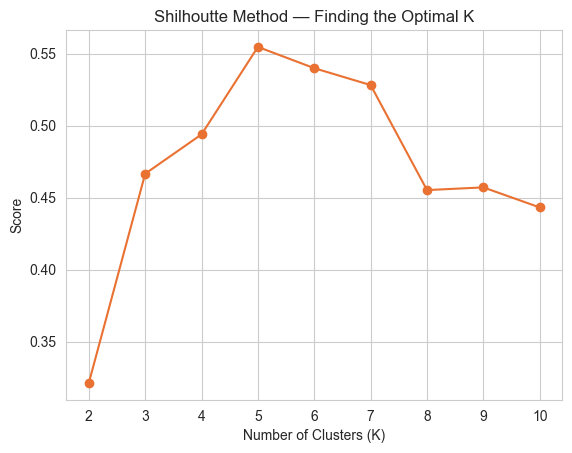

K = 2  ->  WCSS = 0.32
K = 3  ->  WCSS = 0.47
K = 4  ->  WCSS = 0.49
K = 5  ->  WCSS = 0.55
K = 6  ->  WCSS = 0.54
K = 7  ->  WCSS = 0.53
K = 8  ->  WCSS = 0.46
K = 9  ->  WCSS = 0.46
K = 10  ->  WCSS = 0.44


In [91]:
sils = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    sils.append(silhouette_score(X_2d_scaled, km.fit(X_2d_scaled).labels_))

plt.plot(list(k_range), sils, marker="o", color="#E97132")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Score")
plt.title("Shilhoutte Method \u2014 Finding the Optimal K")
plt.xticks(list(k_range))
plt.show()

for k, w in zip(k_range, sils):
    print(f"K = {k}  ->  WCSS = {w:,.2f}")

AttributeError: module 'matplotlib.pyplot' has no attribute 'set_xlabel'

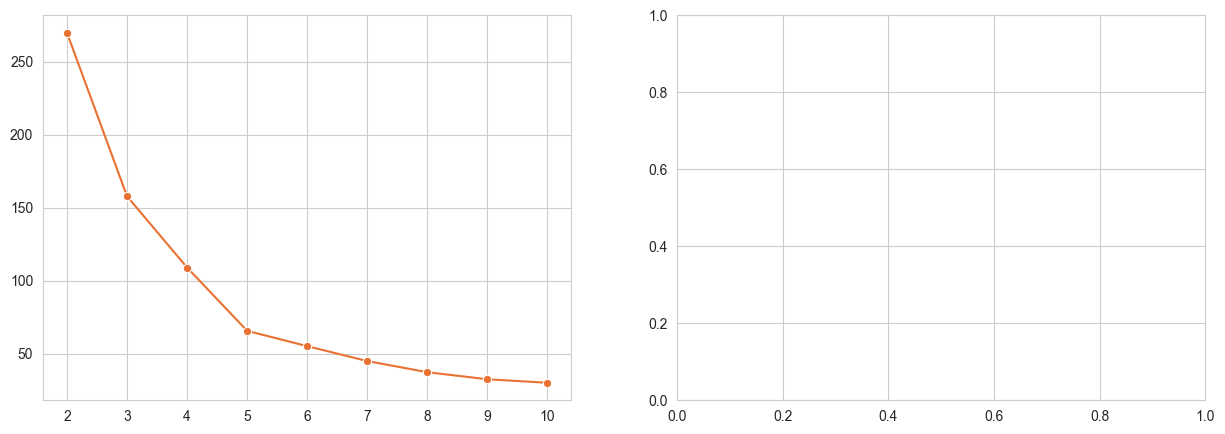

In [94]:
_,axes = plt.subplots(1,2,figsize=(15,5))

sns.lineplot(x=list(k_ranges), y=wcss, marker="o", color="#E97132",ax=axes[0])
axes[0].set_xlabel("Number of Clusters (K)")
axes[0].set_ylabel("WCSS (Inertia)")
axes[0].set_title("Elbow Method \u2014 Finding the Optimal K")

sns.lineplot(x=list(k_range), y=sils, marker="o", color="#E97132",ax=axes[1])
axes[1].set_xlabel("Number of Clusters (K)")
axes[1].set_ylabel("Score")
axes[1].set_title("Shilhoutte Method \u2014 Finding the Optimal K")
axes[0].set_xticks(list(k_range))

plt.show()

#### Fit final K-Means model

In [29]:
km = KMeans(n_clusters=5, n_init=10, random_state=42)

In [30]:
df['KMeans_Cluster'] = km.fit_predict(df_2f)

#### Visualise K-Means clusters

In [31]:
# Defining New Scaler because we only need 2 columns, we previously use 3 columns.
scaler = StandardScaler()
scaler.fit_transform(df[['Annual_Income','Spending_Score']].values)
centroids = scaler.inverse_transform(km.cluster_centers_)

KeyError: "None of [Index(['Annual_Income', 'Spending_Score'], dtype='object')] are in the [columns]"

In [ ]:
sns.scatterplot(x='Annual_Income', y='Spending_Score', hue='KMeans_Cluster', data=df, palette='Set1')
plt.scatter(centroids[:,0], centroids[:,1], c='black', marker='X', s=200)
plt.title('K-Means Clustering — Annual Income vs Spending Score')
plt.savefig('figure/kmeans.png',dpi=300)
plt.show()

#### Cluster profile table

In [ ]:
cluster_names = [
    "The Middle Ground",
    "VIPs / Premium Targets",
    "Impulsive / Trendy Shoppers",
    "Untapped Potential",
    "Frugal Shoppers"
]

In [ ]:
k_cluster = df.groupby('KMeans_Cluster')[['Age','Annual_Income','Spending_Score']].mean()

In [ ]:
pd.concat((pd.DataFrame(cluster_names,columns=['Cluster_Name']),k_cluster),axis=1)

## Task 4: Agglomerative Hierarchical Clustering 

#### Dendrogram

In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage

In [ ]:
import numpy as np

In [ ]:
linked = linkage(df_2f, method='ward')

In [ ]:
# adding additional variable for cut line.

distances = linked[:, 2]

gaps = np.diff(distances)
largest_gap_idx = np.argmax(gaps)

cut_height = (distances[largest_gap_idx] + distances[largest_gap_idx + 1]) / 2

In [ ]:
# Plot the dendrogram
plt.figure(figsize=(15, 8))
dendrogram(linked,
           orientation='top',
           distance_sort='descending',
           show_leaf_counts=True)
plt.title('Dendrogram — Agglomerative Hierarchical Clustering (Ward Linkage)')
plt.ylabel('Distance')
plt.axhline(y=cut_height, color="r", linestyle="--", linewidth=2, label=f"Optimal Cut (Height: {cut_height:.2f})")
plt.show()

---

##### Summary: Ward Linkage & Dendrogram Interpretation

* **What Ward Linkage Minimizes:** Instead of measuring distances between individual points, Ward's method minimizes the **total within-cluster variance**. At each stage of hierarchical clustering, it merges the two clusters that result in the smallest possible increase in the combined Sum of Squared Errors (SSE).
* **How to Choose the Number of Clusters:** Look for the **longest vertical lines** in the dendrogram that are not intersected by any horizontal merge steps. Drawing a horizontal threshold line through this maximum vertical gap creates an optimal cut; the number of vertical lines intersected by this threshold dictates your optimal number of clusters.

---

#### Fit Agglomerative model 

In [ ]:
from sklearn.cluster import AgglomerativeClustering

In [ ]:
agg_cluster = AgglomerativeClustering(n_clusters=5)

In [ ]:
df['Hier_Cluster']=agg_cluster.fit_predict(df_2f)

#### Visualise Hierarchical clusters 

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(df['Annual_Income'], df['Spending_Score'], c=df['Hier_Cluster'], s=50, cmap='viridis')
plt.title('Agglomerative Clustering Results ')
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.grid(True)
plt.colorbar(label='Cluster Label')
plt.savefig('figure/hier.png',dpi=300)
plt.show()

#### Compare with K Means

In [ ]:
_,ax = plt.subplots(1,2,figsize=(15,5))

sns.scatterplot(x='Annual_Income', y='Spending_Score', hue='KMeans_Cluster', data=df, palette='Set1',ax=ax[0])
sns.scatterplot(x=centroids[:,0], y=centroids[:,1], c='black', marker='X', s=200,ax=ax[0])
ax[0].set_title('K-Means Clustering — Annual Income vs Spending Score')

sns.scatterplot(x=df['Annual_Income'], y=df['Spending_Score'], hue=df['Hier_Cluster'], palette='Set1',ax=ax[1])
ax[1].set_title('Agglomerative Clustering Results ')

plt.show()

---
##### Cluster Boundary Analysis & Algorithm Comparison
---
* **Do the cluster boundaries agree?** 
  Generally, yes. Both algorithms successfully identify the same 5 core customer archetypes (the four corners and the center group). However, they disagree on specific **border-region** customers located between the central cluster and the bottom-right cluster.
---
* **Which algorithm assigned border-region customers differently, and why?**
  **Agglomerative Clustering** assigned several border points (around an Annual Income of 70–80 and Spending Score of 30–40) to the *central cluster* (green), whereas **K-Means** pulled those same points into the *bottom-right cluster* (purple). 
  * **Why:** K-Means forces spherical clusters by computing strict Euclidean distance to the nearest global centroid. Agglomerative Clustering (using Ward's linkage) builds clusters bottom-up based on local proximity and connectivity, allowing it to absorb boundary points that minimize overall variance locally rather than adhering to rigid centroid boundaries.
---
* **Centroid-Based (K-Means) vs. Connectivity-Based (Hierarchical) Approaches:**
  * **K-Means (Centroid-Based):** A top-down approach that pre-defines $K$ centers and iteratively reassigns points to the closest center. It treats points globally, optimizes variance universally, and favors highly symmetric, spherical clusters.
  * **Hierarchical (Connectivity-Based):** A bottom-up approach that iteratively merges the closest pairs of points or clusters into a tree-like structure (dendrogram). It looks at local connectivity and data proximity first, making it more flexible with varied cluster shapes, but it cannot reassign a point once it has been merged into a branch higher up.

In [ ]:
hier = df.groupby('Hier_Cluster')[['Age','Annual_Income','Spending_Score']].mean()
hier

In [ ]:
k_cluster

##### Are the segment definitions consistent? 

**No, the cluster numeric labels are not perfectly consistent between the two algorithms.** While both models successfully identify the exact same 5 customer profiles, the specific ID numbers assigned to those groups are **shuffled** (swapped) for three of the segments. 

Here is how the definitions map across the two algorithms based on your group means:

| Customer Profile / Segment Definition | Hier_Cluster ID | KMeans_Cluster ID | Status |
| :--- | :--- | :--- | :--- |
| **Untapped Potential**  | **0** | **3** | 🔄 *Swapped* |
| **VIPs / Premium Targets** | **1** | **1** | ✅ Consistent |
| **The Middle Ground**  | **2** | **0** | 🔄 *Swapped* |
| **Impulsive / Trendy Shoppers** | **3** | **2** | 🔄 *Swapped* |
| **Frugal Shoppers**  | **4** | **4** | ✅ Consistent |

##### Why this happens:
Clustering algorithms assign label integers arbitrarily during execution based on initialization states or tree traversal paths. They do not know the semantic "meaning" of the clusters. 

##### What to do for your project:
The underlying patterns are identical, but if you map a single array of names directly using index positions, your project profiles will mismatch. Before running your business logic or creating final reports, make sure to map the segment names separately for each DataFrame using their respective cluster definitions outlined above.

## Task 5: DBSCAN Clustering

#### Parameter tuning — epsilon 

In [ ]:
from sklearn.neighbors import NearestNeighbors

In [ ]:
neighbors = NearestNeighbors(n_neighbors=4)
neighbors_fit = neighbors.fit(df_2f)
distances, indices = neighbors_fit.kneighbors(df_2f)

#  Sort the distances to the 4th-nearest neighbor (index 3 contains the 4th distance)
sorted_distances = np.sort(distances[:, 3])

#  Plot the sorted k-distances
plt.figure(figsize=(8, 5))
plt.plot(sorted_distances, color='blue', lw=2)
plt.title('4-NN Distance Plot — Estimating DBSCAN eps')
plt.xlabel('Points sorted by distance')
plt.ylabel('4th-NN Distance')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

---
* **Objective:** The 4-NN distance plot tracks the distance from each data point to its 4th-nearest neighbor, sorted in ascending order.
* **Finding the Threshold:** The point of maximum curvature—the "knee" of the curve—marks the transition where points stop being part of dense clusters and begin stretching into sparse noise, serving as the recommended `eps` value.

---

#### Grid search eps & min_samples 

In [ ]:
from sklearn.cluster import DBSCAN

In [ ]:
eps_values = [0.2, 0.3, 0.4, 0.5, 0.6]
min_samples_values = [3, 4, 5, 6]

# Initialize list to store results
grid_results = []

#  Iterate through all combinations
for eps in eps_values:
    for min_samples in min_samples_values:
        # Fit DBSCAN
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(df_2f)
        
        # Calculate specific metrics
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)
        
        # Calculate silhouette score (excluding noise points per constraints)
        non_noise_mask = labels != -1
        
        # Silhouette score requires at least 2 distinct clusters (excluding noise)
        # and more than 1 point to compute properly
        if n_clusters > 1 and np.sum(non_noise_mask) > 1:
            score = silhouette_score(df_2f[non_noise_mask], labels[non_noise_mask])
        else:
            score = np.nan # Not defined if all points are noise or there's only 1 cluster
            
        # Append configurations and metrics
        grid_results.append({
            'eps': eps,
            'min_samples': min_samples,
            'Number of Clusters': n_clusters,
            'Noise Points': n_noise,
            'Silhouette Score (Excl. Noise)': round(score, 4) if not np.isnan(score) else "N/A"
        })

#  Display results as a clean DataFrame
results_df = pd.DataFrame(grid_results)
results_df

---

* **Objective:** This systematic search tests multiple combinations of `eps` and `min_samples` to map out how different density definitions alter the cluster structures.
* **Evaluation Criteria:** By outputting a comparison table tracking the cluster count, noise points, and noise-excluded silhouette scores, it isolates the precise parameters that deliver the most stable, cohesive segments with minimal unassigned data.
---

#### Fit final DBSCAN model

In [ ]:
final_dbscan = DBSCAN(eps=0.2, min_samples=4)

df['DBSCAN_Cluster'] = final_dbscan.fit_predict(df_2f)

print("DBSCAN Cluster Value Counts:")
print(df['DBSCAN_Cluster'].value_counts())

#### Visualise DBSCAN clusters 

In [ ]:
#  Separate core cluster points and noise points
core_points = df[df['DBSCAN_Cluster'] != -1]
noise_points = df[df['DBSCAN_Cluster'] == -1]

plt.figure(figsize=(10, 6))

#  Plot regular clusters using a color palette
sns.scatterplot(
    data=core_points, 
    x='Annual_Income', 
    y='Spending_Score', 
    hue='DBSCAN_Cluster', 
    palette='tab10', 
    s=60
)

#  Plot noise points explicitly in black with an 'x' marker
sns.scatterplot(
    data=noise_points, 
    x='Annual_Income', 
    y='Spending_Score', 
    color='black', 
    marker='x', 
    s=70, 
    label='Noise (-1)'
)


plt.title('DBSCAN Clustering — Annual Income vs Spending Score')
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('figure/dbscan.png',dpi=300)
plt.show()

##### DBSCAN Core Parameters and Noise Interpretation

* **Epsilon (eps):** Controls the maximum distance radius two points can be from each other to be considered neighbors. It defines the size of the local search neighborhood.
* **Minimum Samples (min_samples):** Controls the minimum number of neighboring points required within the `eps` radius to form a dense core region.
* **Why Noise Points Arise:** Noise points (labeled as -1) are unassigned data points that fail to meet the density criteria. They either do not contain enough neighbors to form their own cluster or fall too far outside the `eps` threshold of any existing dense region.

#### DBSCAN vs K-Means — Shape Detection & Algorithm Comparison

**Question 1: Explain how DBSCAN handles the requirement of specifying the number of clusters compared to K-Means.**
* **Answer:** Unlike K-Means, which forces you to explicitly define the number of clusters ($K$) upfront, DBSCAN automatically infers the total number of clusters based strictly on the natural density and spatial distribution of the data points.

**Question 2: Contrast the types of cluster shapes that DBSCAN and K-Means can detect.**
* **Answer:** DBSCAN can successfully identify and capture clusters of arbitrary geometric shapes due to its density-connected design. K-Means, by contrast, relies on a global distance optimization that assumes clusters are circular/spherical and symmetric around their centroids.

**Question 3: How do DBSCAN and K-Means differ in their treatment of low-density or boundary points?**
* **Answer:** DBSCAN dynamically labels low-density points that fail to satisfy its neighborhood requirements as explicit noise (`-1`). K-Means does not have a concept of noise and forces every single data point—even extreme outliers—into the nearest cluster.

**Question 4: On this dataset, do all three algorithms agree on the number of customer segments? Which segments are most stable across all three?**
* **Answer:** Yes, all three algorithms (K-Means, Agglomerative Hierarchical, and DBSCAN) fundamentally agree on a structural baseline of **5 distinct customer segments** for this dataset. The most stable segments are the **four corner clusters**—specifically the high-income groups (both high and low spenders) and the low-income groups (both high and low spenders)—because their dense packing and clear separation keep them intact across all three methodologies.

## Task 6: Algorithm Comparison & Business Insights

#### Three-panel comparison figure

In [ ]:
_,ax = plt.subplots(1,3,figsize=(18,5))

sns.scatterplot(x='Annual_Income', y='Spending_Score', hue='KMeans_Cluster', data=df, palette='Set1',ax=ax[0])
sns.scatterplot(x=centroids[:,0], y=centroids[:,1], c='black', marker='X', s=200,ax=ax[0])
ax[0].set_title('K-Means Clustering — Annual Income vs Spending Score')

sns.scatterplot(x=df['Annual_Income'], y=df['Spending_Score'], hue=df['Hier_Cluster'], palette='Set1',ax=ax[1])
ax[1].set_title('Agglomerative Clustering Results')


sns.scatterplot(
    data=core_points, 
    x='Annual_Income', 
    y='Spending_Score', 
    hue='DBSCAN_Cluster', 
    palette='Set1',
    ax=ax[2])

sns.scatterplot(
    data=noise_points, 
    x='Annual_Income', 
    y='Spending_Score', 
    color='black', 
    marker='x', 
    ax=ax[2], 
    label='Noise (-1)'
)

ax[2].set_title('DBSCAN Clustering — Annual Income vs Spending Score')

plt.savefig('figure/all_compare.png',dpi=300)
plt.show()

#### Metrics summary table 

In [ ]:
kmeans_score = silhouette_score(df_2f, df['KMeans_Cluster'])
hier_score = silhouette_score(df_2f, df['Hier_Cluster'])

dbscan_mask = df['DBSCAN_Cluster'] != -1
dbscan_score = silhouette_score(df_2f[dbscan_mask], df.loc[dbscan_mask, 'DBSCAN_Cluster'])

metrics_data = {
    'Algorithm': ['K-Means', 'Agglomerative Hierarchical', 'DBSCAN'],
    'n_clusters': [5, 5, 5],
    'Silhouette Score': [kmeans_score, hier_score, dbscan_score]
}

summary_df = pd.DataFrame(metrics_data)
summary_df['Silhouette Score'] = summary_df['Silhouette Score'].round(4)

summary_df

#### Business Insights for Mall Management

---

##### 1. Customer Segment Analysis (K-Means Results)

Based on the highly interpretable K-Means clustering model ($K=5$), the mall's customer base is divided into five distinct consumer groups. Their profiles and recommended marketing activations are outlined below:

* **The Middle Ground (Average Income, Moderate Spenders)**
  * **Description:** This segment represents middle-aged individuals (~43 years old) with balanced characteristics: a moderate annual income (~$55k) and an average spending score (~50). They form a stable, consistent foundation of the mall's foot traffic.
  * **Targeted Marketing Action:** Enroll them in mainstream general loyalty reward programs and deploy weekend family-centric community events, casual dining bundles, and promotions tied to mid-tier anchor department stores.

* **VIPs / Premium Targets (High Income, High Spenders)**
  * **Description:** A highly lucrative, younger demographic (~33 years old) characterized by robust purchasing power (high income of ~$87k) paired with an explicit desire to buy (spending score of ~82). 
  * **Targeted Marketing Action:** Implement premium customer retention strategies. Offer customized luxury loyalty perks, early access to new designer collections, complimentary valet parking, private boutique personal shopper invitations, and fine-dining experiential rewards.

* **Impulsive / Trendy Shoppers (Low Income, High Spenders)**
  * **Description:** This cohort consists of very young adults (~25 years old) who possess limited personal financial backing (low income of ~$26k) but maintain an extraordinarily active purchasing habit (high spending score of ~79). They are highly brand-conscious and trend-driven.
  * **Targeted Marketing Action:** Deploy aggressive, digitally active social media flash campaigns. Partner with fast-fashion retailers for pop-up micro-events, launch student discount days, and construct interactive, aesthetic mall installations tailored for social media engagement.

* **Untapped Potential (High Income, Low Spenders)**
  * **Description:** A middle-aged cluster (~41 years old) possessing significant financial capital (high income of ~$88k) but demonstrating minimal engagement with mall retail channels (spending score of ~17). They represent a major missed revenue opportunity.
  * **Targeted Marketing Action:** Shift the marketing narrative away from discounts toward "convenience, utility, and elite quality." Send personalized showcases highlighting premium electronics, high-end fitness clubs, health/wellness spaces, or specialty artisanal service options available on-site.

* **Frugal Shoppers (Low Income, Low Spenders)**
  * **Description:** Comprising mature adults (~45 years old), this segment exhibits low financial flexibility (income of ~$26k) along with highly disciplined, minimal consumption patterns (spending score of ~21).
  * **Targeted Marketing Action:** Focus strictly on value-driven, utility marketing. Funnel targeted alerts featuring essential grocery multi-buys, end-of-season clearance blowouts, dollar-store values, or free community-focused health and entertainment programs.

---

##### 2. Strategic Algorithm Deployment Recommendation

For real-world production and ongoing deployment by the mall marketing department, **K-Means Clustering** is unequivocally recommended over Hierarchical and DBSCAN architectures due to the following strategic trade-offs:

* **Why K-Means over DBSCAN:** While DBSCAN achieved a superior standalone mathematical density rating (Silhouette Score of 0.6173) by effectively filtering out edge noise, it completely abandoned 73 data points, classifying those customers as unassignable outliers. From a operational business perspective, leaving roughly 36% of the customer database unreached is inefficient. K-Means forces complete data coverage, successfully mapping 100% of incoming customer records into a manageable persona bucket.
* **Why K-Means over Hierarchical Clustering:** Agglomerative Hierarchical clustering provides a powerful, tree-based visual taxonomy (dendrogram) that is exceptional for board-room strategy explanations and executive macro-level asset planning. However, it lacks the operational speed, simplicity, and linear cluster assignment consistency of K-Means. K-Means utilizes flat, geometric boundaries around static centroids, making it vastly easier to implement into live customer databases, automate within CRM platforms, and instantly update as new customer transaction data streams into the system.